In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, json
import re
import pandas as pd
from itertools import cycle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Global publication settings
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
colors = {
    "Train": "#4C72B0",
    "Test": "#DD8452",
    "Unseen": "#55A868",
}
phases_order = ["Train", "Test", "Unseen"]
bar_width = 0.22

LINE_PATTERN = re.compile(
    r"^(.*?)\s*-\s*"
    r"Acc\s*([\d.]+)\s*\|\s*"
    r"BalAcc\s*([\d.]+)\s*\|\s*"
    r"Sens\s*([\d.]+)\s*\|\s*"
    r"Spec\s*([\d.]+)\s*\|\s*"
    r"AUROC\s*([\d.]+)\s*\|\s*"
    r"pAUROC\s*([\d.]+)"
)

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


In [6]:
RESULT_FILE = "result_overall.txt"
rows = []

LOG_ROOTS = [
    d for d in os.listdir(".")
    if os.path.isdir(d) and d.startswith("logs")
]

for log_root in LOG_ROOTS:
    for experiment in os.listdir(log_root):
        experiment_metadata = experiment.split("_")
        if len(experiment_metadata) == 2:
            delta = "nodelta"
        else:
            delta = experiment_metadata[-1]

        exp_path = os.path.join(log_root, experiment)
        result_path = os.path.join(exp_path, RESULT_FILE)

        if not os.path.isdir(exp_path) or not os.path.isfile(result_path):
            continue

        # validate delta configuration
        config_path = os.path.join(exp_path, "config.json")
        if not os.path.isfile(config_path):
            continue

        with open(config_path) as f:
            config = json.load(f)

        d = config["data"]["delta_feature"]
        dd = config["data"]["deltadelta_feature"]

        if delta == "nodelta" and (d or dd):
            print(f"[WARN] {log_root}/{experiment}: nodelta but delta enabled")

        if delta == "delta" and (not d or dd):
            print(f"[WARN] {log_root}/{experiment}: delta mismatch")

        if delta == "deltadelta" and not (d and dd):
            print(f"[WARN] {log_root}/{experiment}: deltadelta mismatch")
        
        current_phase = None
        with open(result_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                metric_match = LINE_PATTERN.match(line)
                if metric_match:
                    current_phase = metric_match.group(1)

                    rows.append({
                        "log_folder": log_root,
                        "model": experiment_metadata[0],
                        "feature": experiment_metadata[1],
                        "delta": delta,
                        "phase": current_phase,
                        "accuracy": float(metric_match.group(2)),
                        "balanced_accuracy": float(metric_match.group(3)),
                        "sensitivity": float(metric_match.group(4)),
                        "specificity": float(metric_match.group(5)),
                        "auroc": float(metric_match.group(6)),
                        "pauroc": float(metric_match.group(7)),
                    })

df = pd.DataFrame(rows)

In [7]:
df = df[df['log_folder'].isin(["logs_manyloss"])]
#df = df[df['feature'].isin(['logmel', 'peft', 'finetune'])]
#df = df[df['model'].isin(['resnet34', 'bilstm', 'qwenasp', ])]
#df = df[df['feature'].isin(['logmel'])]
#df_mean = df_mean[df_mean['feature'].isin(['logmel'])]

In [11]:
df

,log_folder,model,feature,delta,phase,accuracy,balanced_accuracy,sensitivity,specificity,auroc,pauroc
39,logs_symptoms,coughOnly,logmel,nodelta,Train,0.6984,0.6913,0.6699,0.7126,0.7648,0.0000
40,logs_symptoms,coughOnly,logmel,nodelta,Test,0.6564,0.6536,0.6430,0.6642,0.7070,0.0000
41,logs_symptoms,coughOnly,logmel,nodelta,Unseen,0.3579,0.5586,0.8601,0.2570,0.5983,0.0000
42,logs_symptoms,symptomsOnly,logmel,nodelta,Train,0.6836,0.6580,0.5945,0.7216,0.7244,0.0000
43,logs_symptoms,symptomsOnly,logmel,nodelta,Test,0.6368,0.6404,0.6500,0.6308,0.6562,0.0000
44,logs_symptoms,symptomsOnly,logmel,nodelta,Unseen,0.6187,0.5705,0.5000,0.6410,0.5653,0.0000
45,logs_symptoms,FiLM,logmel,nodelta,Train,0.7169,0.7316,0.7757,0.6876,0.8179,0.0438
46,logs_symptoms,FiLM,logmel,nodelta,Test,0.6397,0.6619,0.7454,0.5784,0.7116,0.0000
47,logs_symptoms,FiLM,logmel,nodelta,Unseen,0.4760,0.6099,0.8112,0.4087,0.6521,0.0000
48,logs_symptoms,gating,logmel,nodelta,Train,0.7567,0.7356,0.6729,0.7983,0.8194,0.0601


In [ ]:
# -----------------------------
# Configuration
# -----------------------------
models = df['model'].unique()
metrics = {
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity", 
    "specificity": "Specificity",
    "auroc": "AUC-ROC",
}
features_order = ['gtgram', 'melspectogram', 'logmel', 'mfcc', 'spectogram']

# -----------------------------
# Plotting
# -----------------------------
for model in models:
    for metric, metric_label in metrics.items():

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        model_df = df[df["model"] == model]
        x = np.arange(len(features_order))

        handles = []
        all_values = []
        for i, phase in enumerate(phases_order):
            phase_df = model_df[model_df["phase"] == phase]
            values = [
                phase_df.loc[phase_df["feature"] == f, metric].values[0]
                for f in features_order
            ]
            all_values.extend([
                phase_df.loc[phase_df["feature"] == f, metric].values[0]
                for f in features_order
            ])

            bars = ax.bar(
                x + (i - 1) * bar_width,
                values,
                width=bar_width,
                color=colors[phase],
                edgecolor="black",
                linewidth=0.6,
                label=phase
            )
            handles.append(bars[0])

        # -------------------------
        # Dynamic Y-axis limits
        # -------------------------
        data_min = min(all_values)
        data_max = max(all_values)

        padding = 0.07  # percentage points

        ymin = 0 if data_min <= 0 else max(0, data_min - padding)
        ymax = 1 if data_max >= 1 else min(1, data_max + padding)
        # -------------------------
        # Axes formatting
        # -------------------------
        ax.set_xticks(x)
        ax.set_xticklabels(features_order)
        ax.set_ylabel(metric_label)
        if metric == "sensitivity" or metric == "specificity":
            ax.set_ylim(0.1, 1.0)

        ax.set_title(f"{model.upper()} – {metric_label}", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)

        # -------------------------
        # Figure-level legend (NO overlap)
        # -------------------------
        fig.legend(
            handles,
            phases_order, 
            loc="lower center",
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.02)
        )

        fig.subplots_adjust(bottom=0.12)
        plt.show()

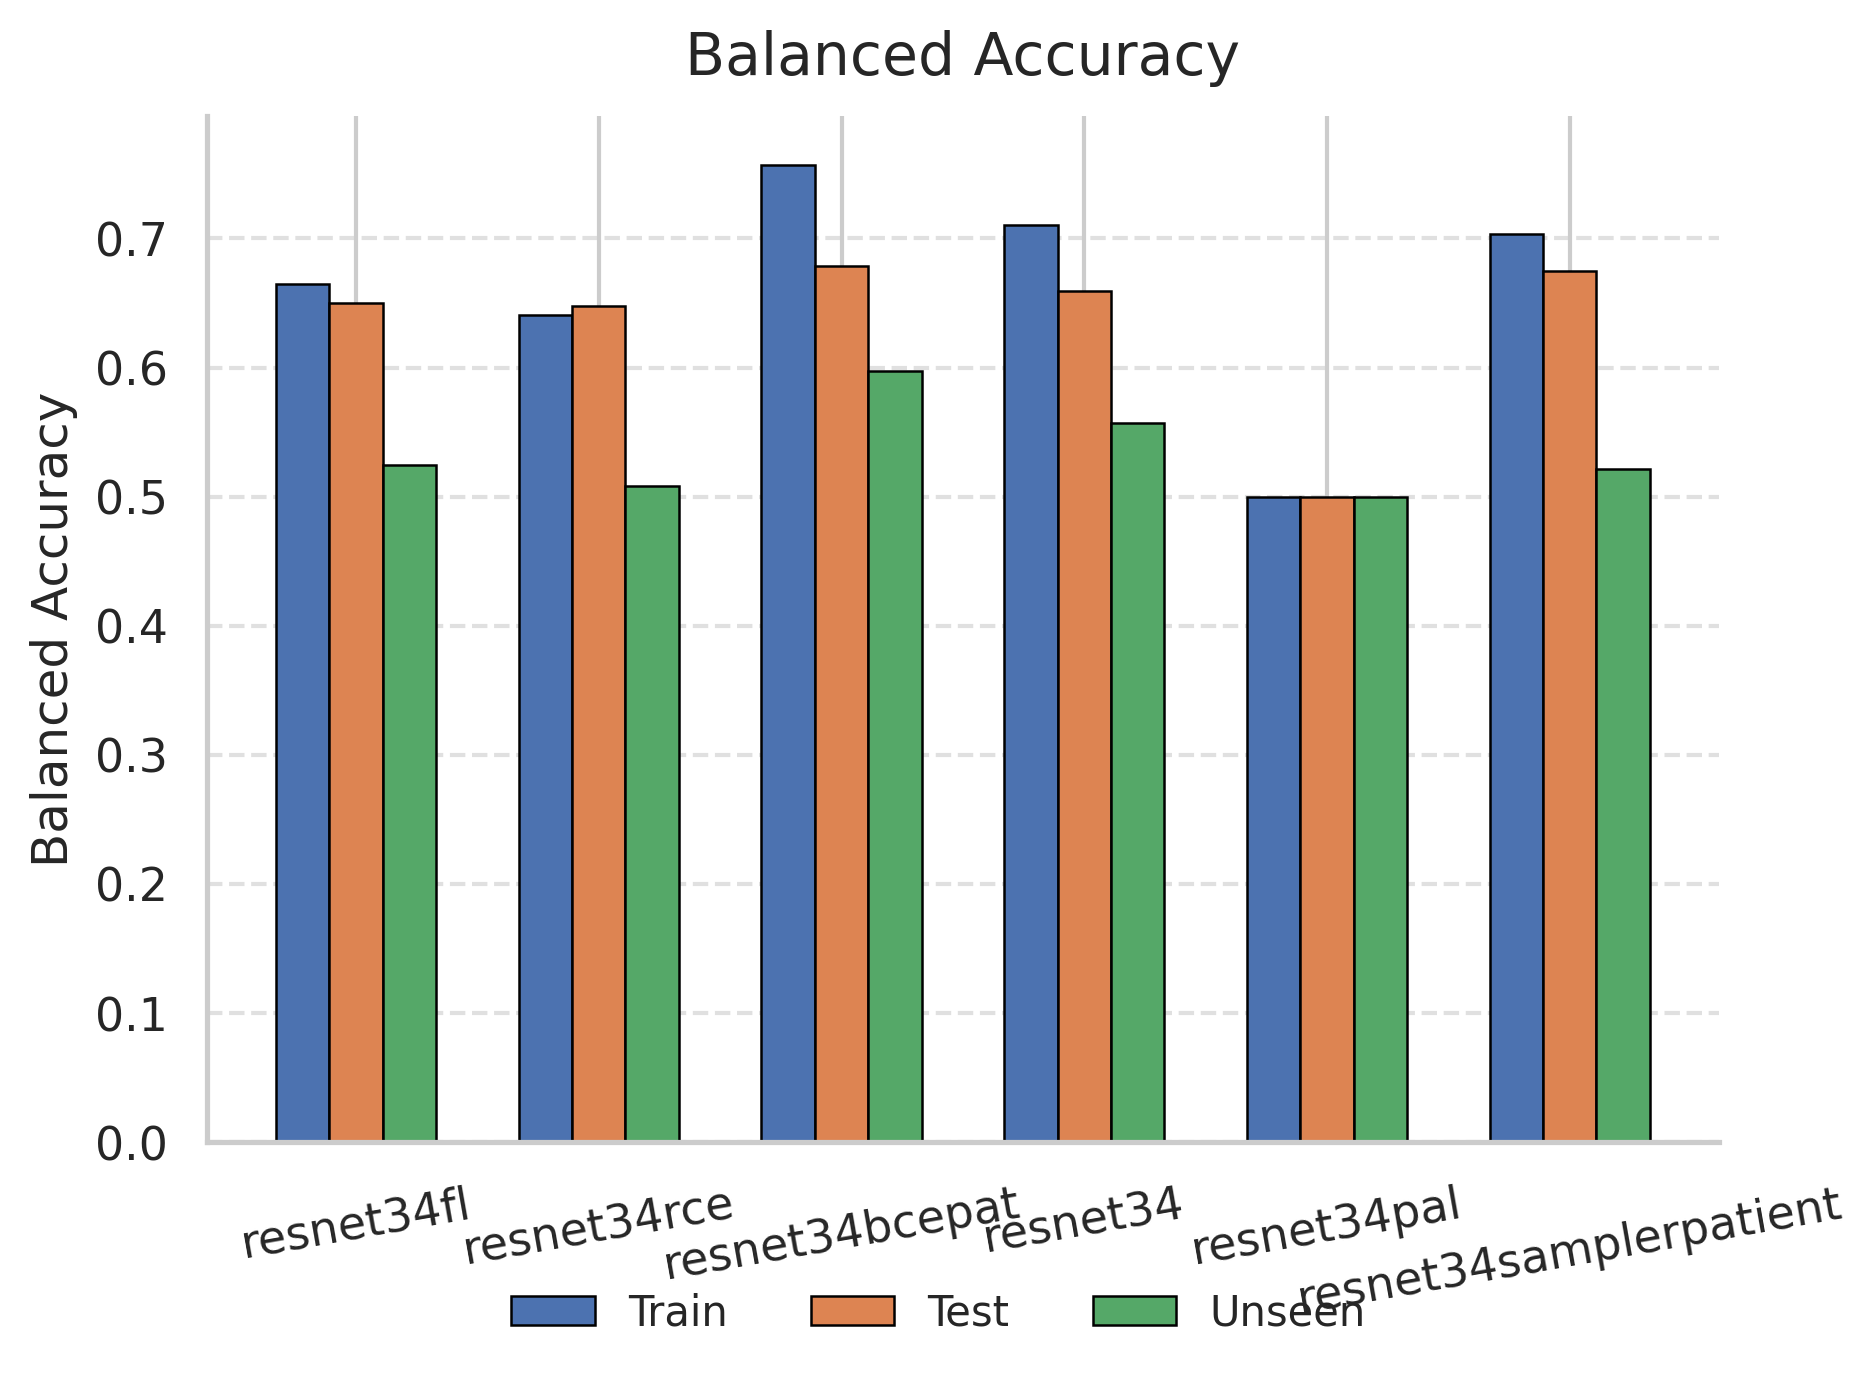

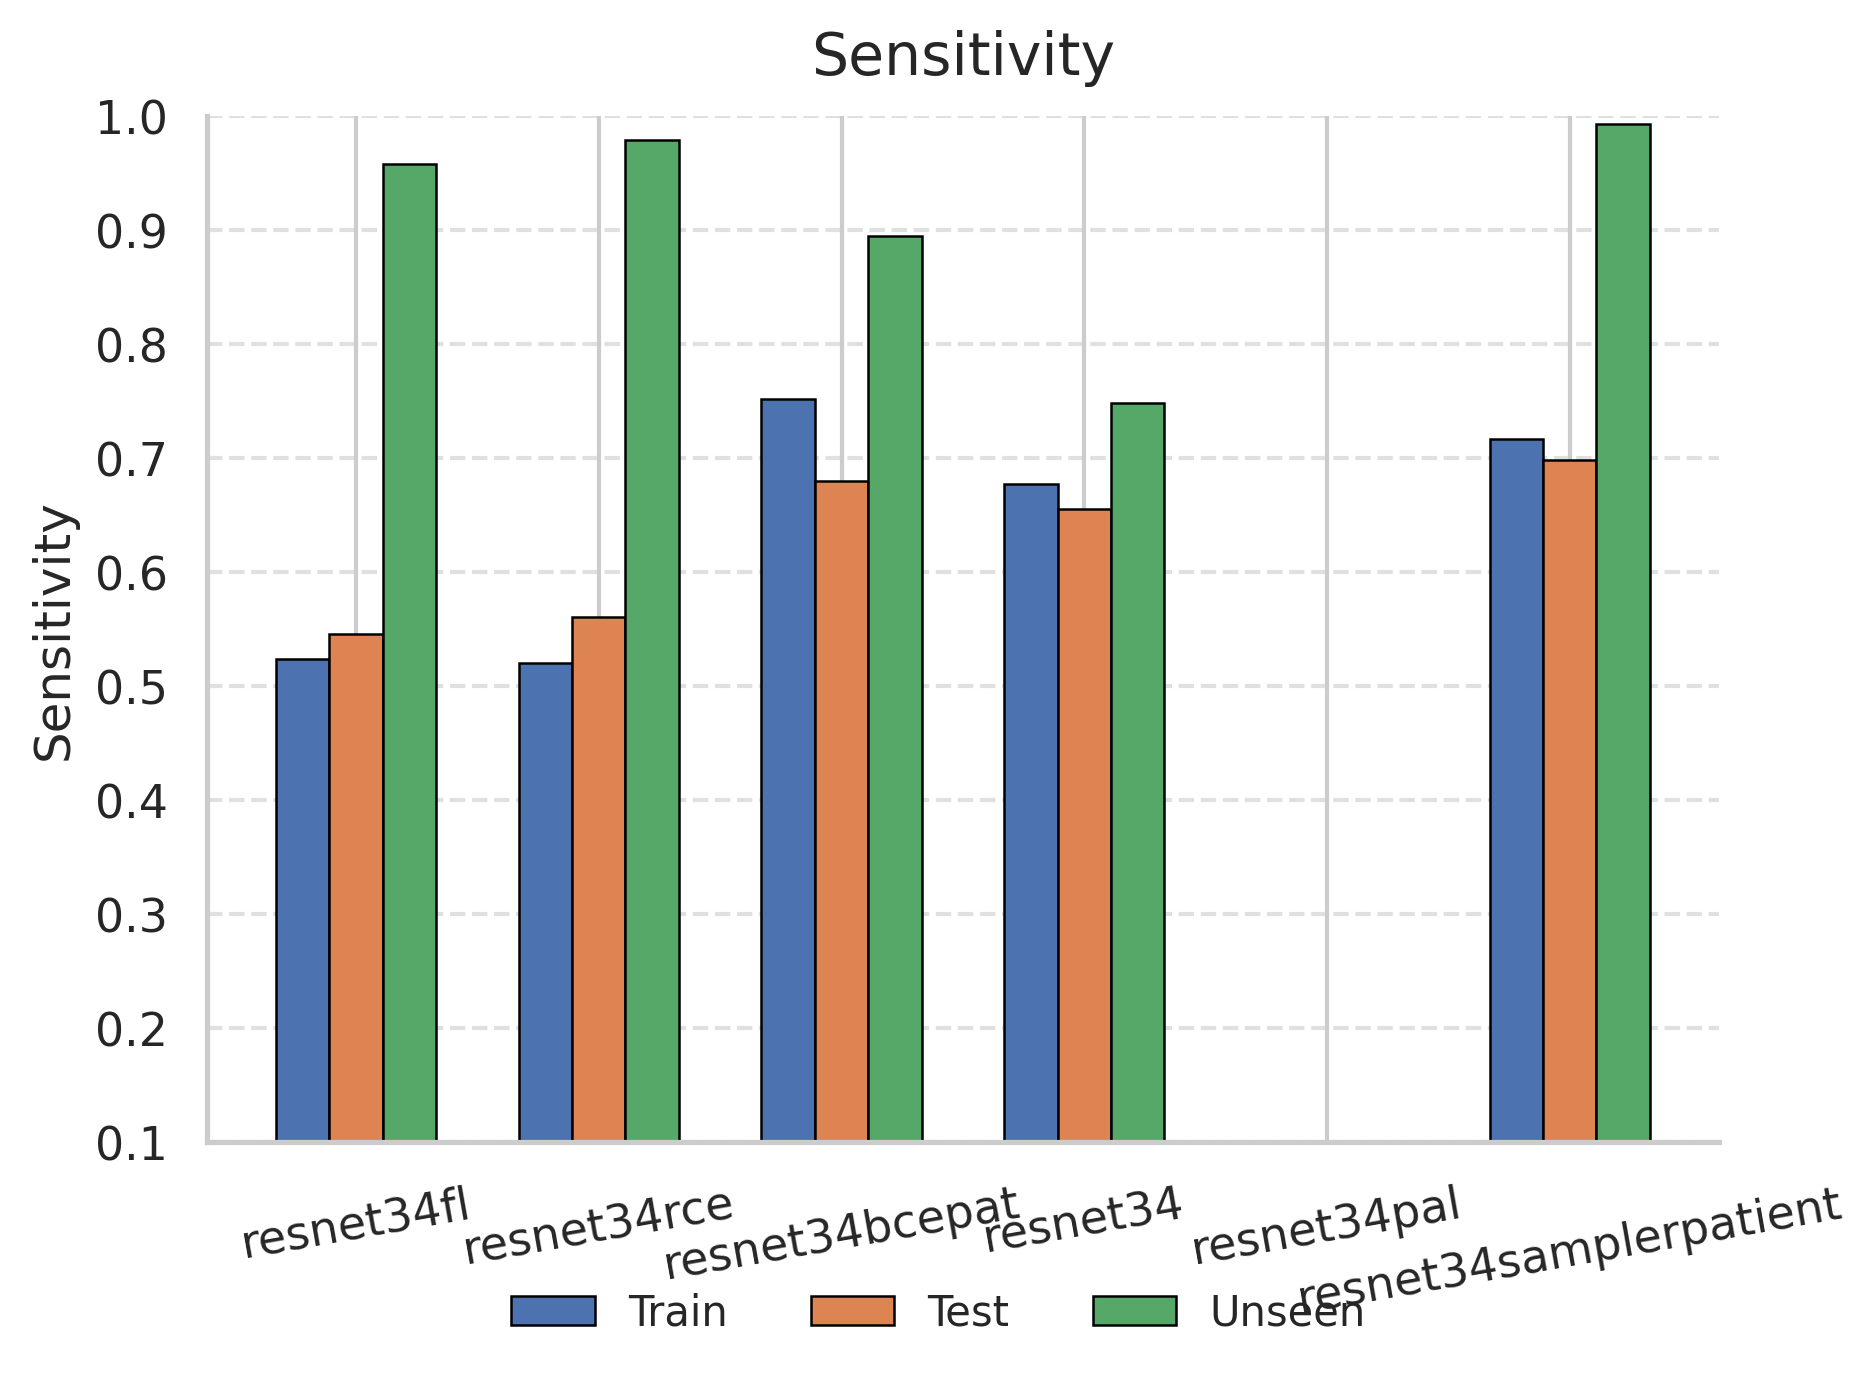

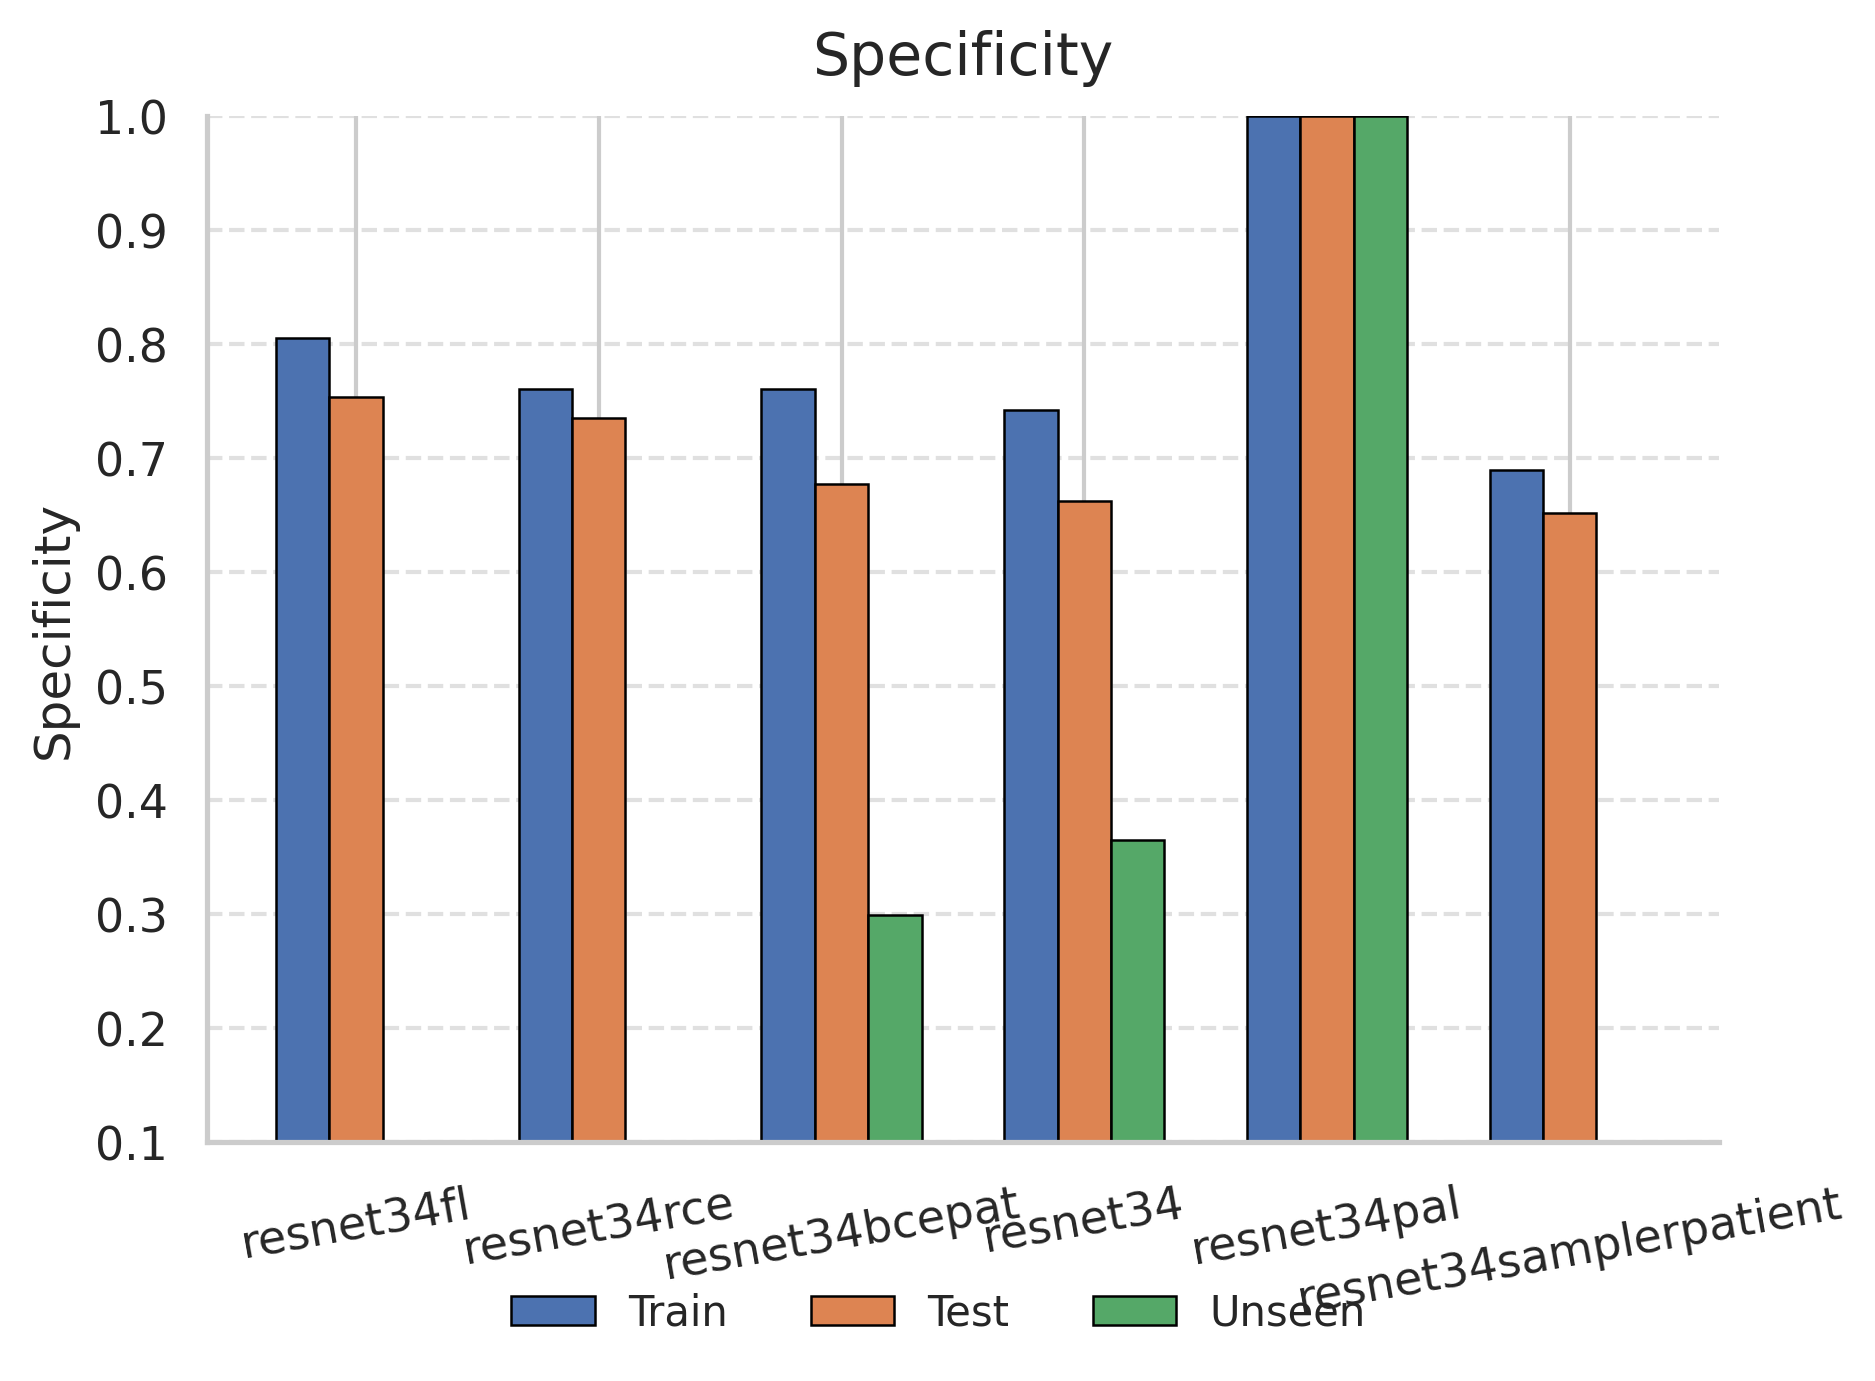

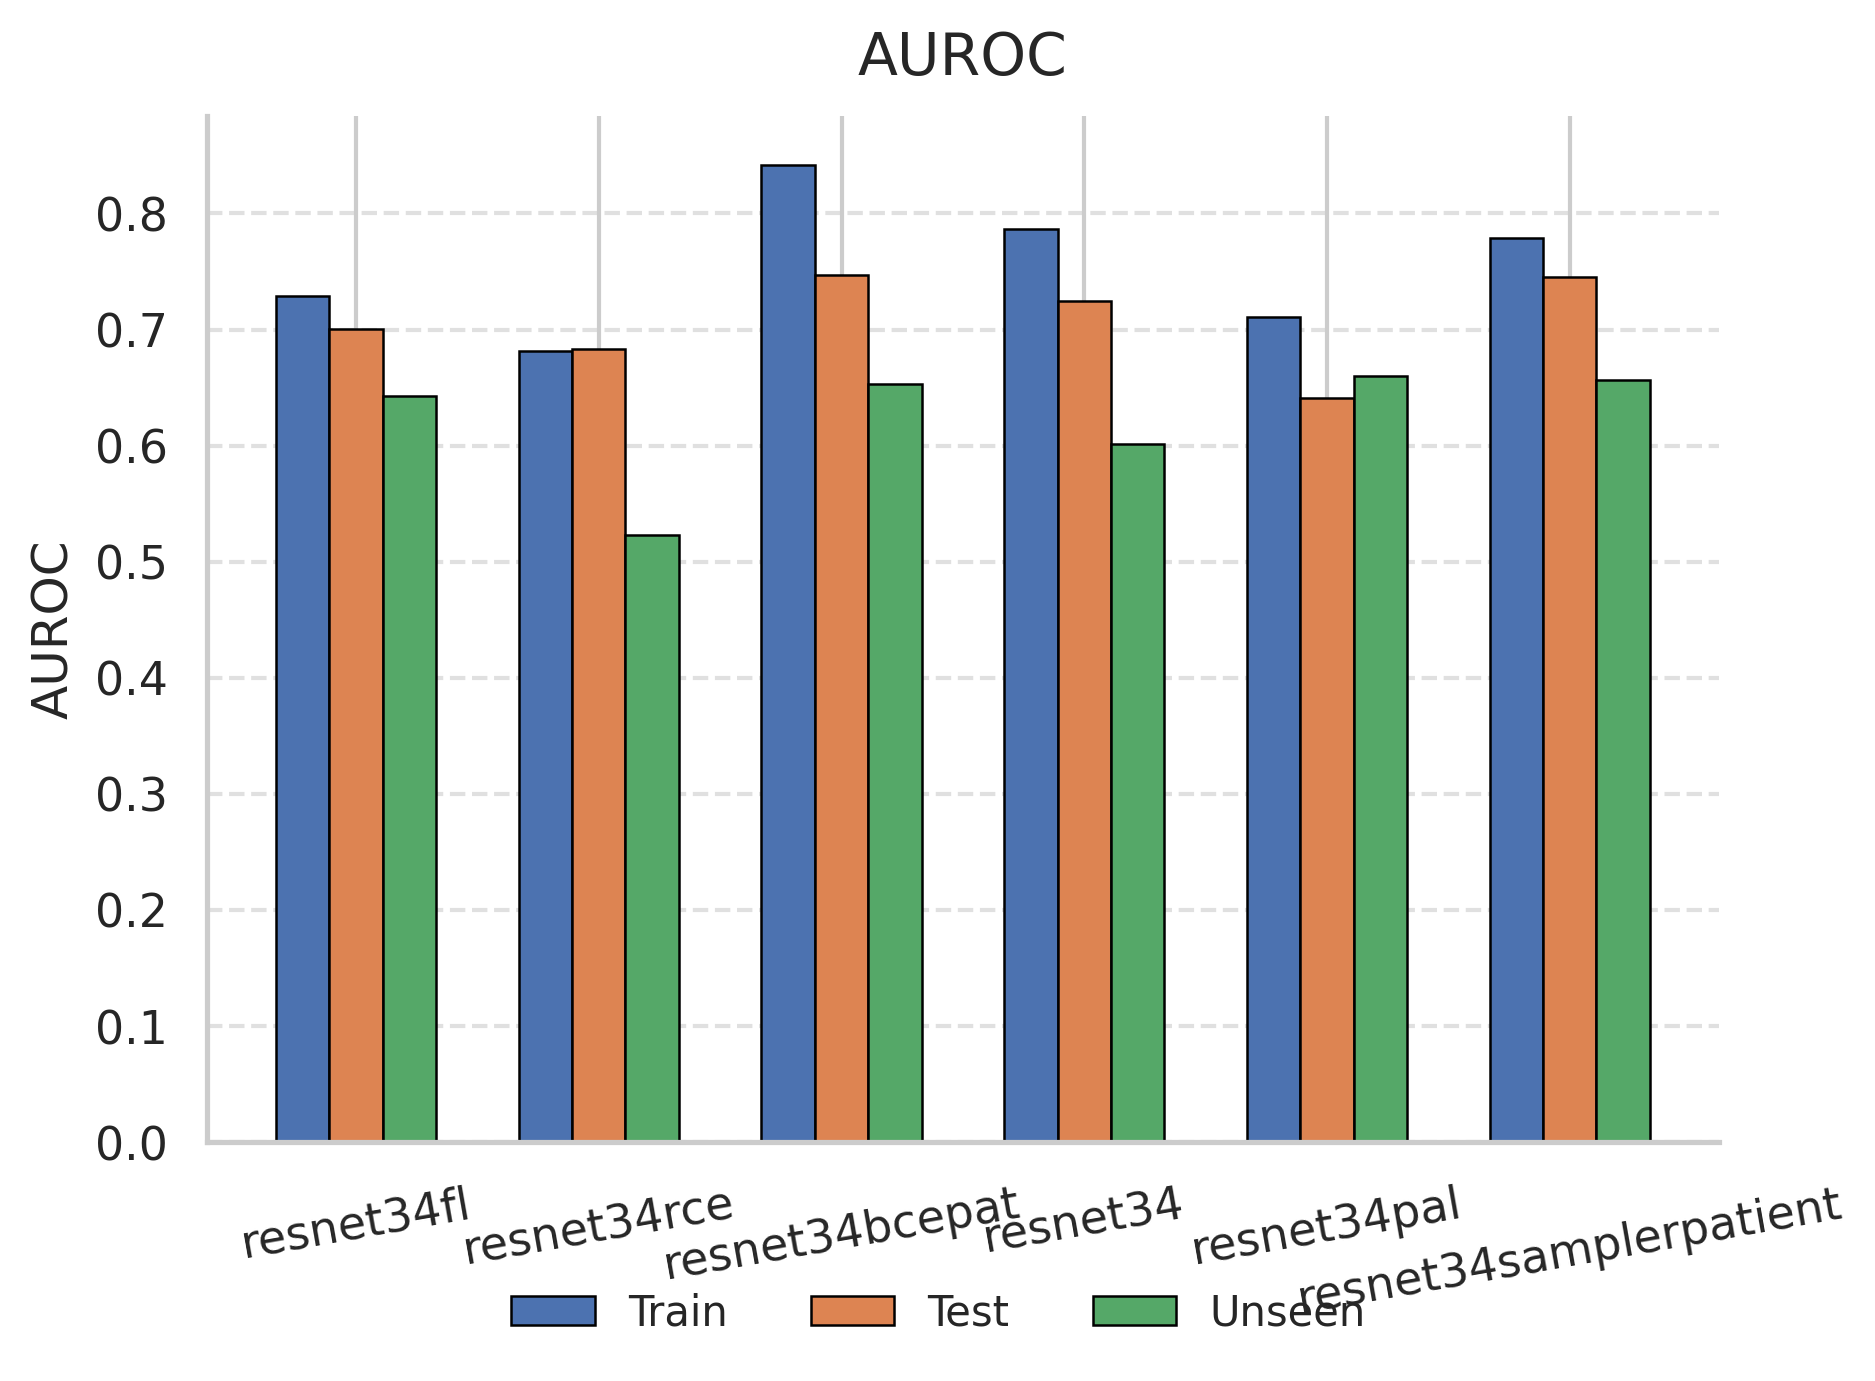

In [8]:
# -----------------------------
# Configuration
# -----------------------------
models = df['model'].unique()
metrics = {
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity", 
    "specificity": "Specificity",
    "auroc": "AUROC",
}

# -----------------------------
# Plotting
# -----------------------------
for metric, metric_label in metrics.items():
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    model_df = df
    x = np.arange(len(models))

    handles = []
    all_values = []
    for i, phase in enumerate(phases_order):
        phase_df = model_df[model_df["phase"] == phase]
        values = [
            phase_df.loc[phase_df["model"] == f, metric].values[0]
            for f in models
        ]
        all_values.extend([
            phase_df.loc[phase_df["model"] == f, metric].values[0]
            for f in models
        ])

        bars = ax.bar(
            x + (i - 1) * bar_width,
            values,
            width=bar_width,
            color=colors[phase],
            edgecolor="black",
            linewidth=0.6,
            label=phase
        )
        handles.append(bars[0])

    # -------------------------
    # Dynamic Y-axis limits
    # -------------------------
    data_min = min(all_values)
    data_max = max(all_values)

    padding = 0.07  # percentage points

    ymin = 0 if data_min <= 0 else max(0, data_min - padding)
    ymax = 1 if data_max >= 1 else min(1, data_max + padding)
    # -------------------------
    # Axes formatting
    # -------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.tick_params(axis='x', labelrotation=10)
    ax.set_ylabel(metric_label)
    if metric == "sensitivity" or metric == "specificity":
        ax.set_ylim(0.1, 1.0)

    ax.set_title(f"{metric_label}", pad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # -------------------------
    # Figure-level legend (NO overlap)
    # -------------------------
    fig.legend(
        handles,
        phases_order, 
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    fig.subplots_adjust(bottom=0.12)
    plt.show()

In [ ]:
df

# Old Version

In [ ]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import os, json
import re
import pandas as pd
from itertools import cycle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Global publication settings
# -----------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
colors = {
    "Train": "#4C72B0",
    "Test": "#DD8452",
    "Unseen": "#55A868",
}
phases_order = ["Train", "Test", "Unseen"]
bar_width = 0.22

PHASE_PATTERN = re.compile(r"=+\s*(Train Phase|Test Phase)\s*=+")
LINE_PATTERN = re.compile(
    r"^(.*?)\s*-\s*"
    r"Acc\s*([\d.]+)\s*\|\s*"
    r"BalAcc\s*([\d.]+)\s*\|\s*"
    r"Sens\s*([\d.]+)\s*\|\s*"
    r"Spec\s*([\d.]+)\s*\|\s*"
    r"AUROC\s*([\d.]+)\s*\|\s*"
    r"pAUROC\s*([\d.]+)"
)

In [ ]:
RESULT_FILE = "result_summary.txt"
rows = []

LOG_ROOTS = [
    d for d in os.listdir(".")
    if os.path.isdir(d) and d.startswith("logs")
]

for log_root in LOG_ROOTS:
    for experiment in os.listdir(log_root):
        experiment_metadata = experiment.split("_")
        if len(experiment_metadata) == 2:
            delta = "nodelta"
        else:
            delta = experiment_metadata[-1]

        exp_path = os.path.join(log_root, experiment)
        result_path = os.path.join(exp_path, RESULT_FILE)

        if not os.path.isdir(exp_path) or not os.path.isfile(result_path):
            continue

        # validate delta configuration
        config_path = os.path.join(exp_path, "config.json")
        if not os.path.isfile(config_path):
            continue

        with open(config_path) as f:
            config = json.load(f)

        d = config["data"]["delta_feature"]
        dd = config["data"]["deltadelta_feature"]

        if delta == "nodelta" and (d or dd):
            print(f"[WARN] {log_root}/{experiment}: nodelta but delta enabled")

        if delta == "delta" and (not d or dd):
            print(f"[WARN] {log_root}/{experiment}: delta mismatch")

        if delta == "deltadelta" and not (d and dd):
            print(f"[WARN] {log_root}/{experiment}: deltadelta mismatch")

        current_phase = None
        with open(result_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                phase_match = PHASE_PATTERN.search(line)
                if phase_match:
                    current_phase = phase_match.group(1).replace(" Phase", "")
                    continue

                metric_match = LINE_PATTERN.match(line)
                if metric_match and current_phase is not None:
                    database = metric_match.group(1)

                    rows.append({
                        "log_folder": log_root,
                        "model": experiment_metadata[0],
                        "feature": experiment_metadata[1],
                        "delta": delta,
                        "phase": current_phase,
                        "database": database,
                        "accuracy": float(metric_match.group(2)),
                        "balanced_accuracy": float(metric_match.group(3)),
                        "sensitivity": float(metric_match.group(4)),
                        "specificity": float(metric_match.group(5)),
                        "auroc": float(metric_match.group(6)),
                        "pauroc": float(metric_match.group(7)),
                    })

df = pd.DataFrame(rows)
df.loc[df['database'] == "CIRDZ", 'phase'] = "Unseen"

# df_unseen = df[df['phase'] == "Unseen"]
# df = df[df['phase'] != "Unseen"]

df_mean = (
    df
    .groupby(
        ['log_folder', "model", "feature", "delta", "phase"],
        as_index=False
    ).mean(numeric_only=True)
)

In [ ]:
df_mean = df_mean[df_mean['log_folder'].isin(["logs_nfft2048", "logs_syptoms"])]
#df_mean = df_mean[df_mean['feature'].isin(['logmel', 'peft'])]
df_mean = df_mean[df_mean['feature'].isin(['logmel'])]

In [ ]:
df_mean

In [ ]:
# -----------------------------
# Configuration
# -----------------------------
models = df_mean['model'].unique()
metrics = {
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity", 
    "specificity": "Specificity",
    "auroc": "AUROC",
}
features_order = ['gtgram', 'melspectogram', 'logmel', 'mfcc', 'spectogram']

# -----------------------------
# Plotting
# -----------------------------
for model in models:
    for metric, metric_label in metrics.items():

        fig, ax = plt.subplots(figsize=(6.5, 4.5))

        model_df = df_mean[df_mean["model"] == model]
        x = np.arange(len(features_order))

        handles = []
        all_values = []
        for i, phase in enumerate(phases_order):
            phase_df = model_df[model_df["phase"] == phase]
            values = [
                phase_df.loc[phase_df["feature"] == f, metric].values[0]
                for f in features_order
            ]
            all_values.extend([
                phase_df.loc[phase_df["feature"] == f, metric].values[0]
                for f in features_order
            ])

            bars = ax.bar(
                x + (i - 1) * bar_width,
                values,
                width=bar_width,
                color=colors[phase],
                edgecolor="black",
                linewidth=0.6,
                label=phase
            )
            handles.append(bars[0])

        # -------------------------
        # Dynamic Y-axis limits
        # -------------------------
        data_min = min(all_values)
        data_max = max(all_values)

        padding = 0.07  # percentage points

        ymin = 0 if data_min <= 0 else max(0, data_min - padding)
        ymax = 1 if data_max >= 1 else min(1, data_max + padding)
        # -------------------------
        # Axes formatting
        # -------------------------
        ax.set_xticks(x)
        ax.set_xticklabels(features_order)
        ax.set_ylabel(metric_label)
        if metric == "sensitivity" or metric == "specificity":
            ax.set_ylim(0.1, 1.0)

        ax.set_title(f"{model.upper()} – {metric_label}", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.6)

        # -------------------------
        # Figure-level legend (NO overlap)
        # -------------------------
        fig.legend(
            handles,
            phases_order, 
            loc="lower center",
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, -0.02)
        )

        fig.subplots_adjust(bottom=0.12)
        plt.show()

In [ ]:
models

In [ ]:
# -----------------------------
# Configuration
# -----------------------------
models = df_mean['model'].unique()
metrics = {
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity", 
    "specificity": "Specificity",
    "auroc": "AUROC",
}

# -----------------------------
# Plotting
# -----------------------------
for metric, metric_label in metrics.items():
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    model_df = df_mean
    x = np.arange(len(models))

    handles = []
    all_values = []
    for i, phase in enumerate(phases_order):
        phase_df = model_df[model_df["phase"] == phase]
        values = [
            phase_df.loc[phase_df["model"] == f, metric].values[0]
            for f in models
        ]
        all_values.extend([
            phase_df.loc[phase_df["model"] == f, metric].values[0]
            for f in models
        ])

        bars = ax.bar(
            x + (i - 1) * bar_width,
            values,
            width=bar_width,
            color=colors[phase],
            edgecolor="black",
            linewidth=0.6,
            label=phase
        )
        handles.append(bars[0])

    # -------------------------
    # Dynamic Y-axis limits
    # -------------------------
    data_min = min(all_values)
    data_max = max(all_values)

    padding = 0.07  # percentage points

    ymin = 0 if data_min <= 0 else max(0, data_min - padding)
    ymax = 1 if data_max >= 1 else min(1, data_max + padding)
    # -------------------------
    # Axes formatting
    # -------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel(metric_label)
    if metric == "sensitivity" or metric == "specificity":
        ax.set_ylim(0.1, 1.0)

    ax.set_title(f"{metric_label}", pad=10)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # -------------------------
    # Figure-level legend (NO overlap)
    # -------------------------
    fig.legend(
        handles,
        phases_order, 
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.subplots_adjust(bottom=0.12)
    plt.show()

In [ ]:
df_mean = (
    df
    .groupby(
        ["model", "feature", "delta", "phase"],
        as_index=False
    ).mean(numeric_only=True)
)
df_mean

In [ ]:
df_mean = (
    df
    .groupby(
        ["model", "feature", "delta", "phase"],
        as_index=False
    ).mean(numeric_only=True)
)

pivot = df_mean.pivot_table(
    index=["model", "feature", "delta"],
    columns="phase",
    values=["accuracy", "auroc"]
)

pivot.columns = [
    f"{'Weighted Acc' if m == 'accuracy' else 'AUC-ROC'} {phase}"
    for m, phase in pivot.columns
]

pivot = pivot.reset_index()

pivot = pivot[
    [
        "model",
        "feature",
        "delta",
        "Weighted Acc Train",
        "Weighted Acc Test",
        "AUC-ROC Train",
        "AUC-ROC Test",
    ]
]

pivot.iloc[:, 3:] = pivot.iloc[:, 3:].round(5)
pivot.to_excel("performance_summary.xlsx", index=False)
pivot.sort_values(by="AUC-ROC Test", ascending=False)

In [ ]:
df = df.sort_values(by=["model", "delta", "feature"]).reset_index(drop=True)

df_train = df[df['phase'] == "Train"]
df_test = df[df['phase'] == "Test"]

df_train.groupby(["model", "feature", "delta"], as_index=False).mean(numeric_only=True).sort_values(by="auroc", ascending=False)

In [ ]:
df_mean_db = (
    df_test
    .groupby(["model", "feature", "delta"], as_index=False)
    .mean(numeric_only=True)
)

df_sort = df_mean_db.sort_values(by="auroc", ascending=False)#.head(5)
df_mean_db.sort_values(by="auroc", ascending=False)

In [ ]:
df_mean_db = (
    df_unseen
    .groupby(["model", "feature", "delta"], as_index=False)
    .mean(numeric_only=True)
)
df_mean_db.sort_values(by="auroc", ascending=False)

In [ ]:
delta_order = {
    "nodelta": 0,
    "delta": 1,
    "deltadelta": 2,
}

def feature_level_label(row):
    if row["delta"] == "nodelta":
        return row["feature"]
    elif row["delta"] == "delta":
        return f"{row['feature']}Δ"
    elif row["delta"] == "deltadelta":
        return f"{row['feature']}ΔΔ"
    else:
        return f"{row['feature']}_{row['delta']}"
    
df_mean["feature_level"] = df_mean.apply(feature_level_label, axis=1)
x_order = ['spectogram',
       'spectogramΔ', 'spectogramΔΔ', 'mfcc', 'mfccΔ', 'mfccΔΔ', 'melspectogram', 'melspectogramΔ',
       'melspectogramΔΔ', 'gtgram', 'gtgramΔ', 'gtgramΔΔ']

df_mean["feature_order"] = df_mean["feature"]
df_mean["delta_order"] = df_mean["delta"].map(delta_order)
df_mean = df_mean.sort_values(
    by=["feature_order", "delta_order"]
).reset_index(drop=True)

In [ ]:
model_name = "resnet34" # bilstm resnet34
df_plot = df_mean[df_mean["model"] == model_name]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

# ---- LEFT: Accuracy ----
sns.barplot(
    data=df_plot,
    x="feature_level",
    y="accuracy",
    hue="phase",
    order=x_order,
    hue_order=["Train", "Test"],
    ax=axes[0],
)

axes[0].set_title(f"{model_name} – Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel("Feature / Feature Level")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# ---- RIGHT: AUROC ----
sns.barplot(
    data=df_plot,
    x="feature_level",
    y="auroc",
    hue="phase",
    order=x_order,
    hue_order=["Train", "Test"],
    ax=axes[1],
)

axes[1].set_title(f"{model_name} – AUROC")
axes[1].set_ylabel("AUROC")
axes[1].set_xlabel("Feature / Feature Level")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

axes[0].set_ylim(0.5, 0.90)  # Accuracy
axes[1].set_ylim(0.5, 0.90)  # AUROC (adjust upper if needed)

# ---- Shared formatting ----
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
    ax.legend_.remove()

# Single shared legend (bottom-left of figure)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()


In [ ]:
metrics = {
    "accuracy": "Weighted Acc",
    "auroc": "AUC-ROC",
}

df_sel = df[
    ["feature", "delta", "phase", "accuracy", "auroc"]
].copy()

# Pivot
pivot = df_sel.pivot_table(
    index=["feature", "delta"],
    columns="phase",
    values=list(metrics.keys()),
)

# Flatten MultiIndex columns
pivot.columns = [
    f"{metrics[m]} {phase}"
    for m, phase in pivot.columns
]

pivot = pivot.reset_index()

ordered_cols = [
    "feature",
    "delta",
    "Weighted Acc Train",
    "Weighted Acc Test",
    "AUC-ROC Train",
    "AUC-ROC Test",
]

pivot = pivot[ordered_cols]
pivot.iloc[:, 2:] = pivot.iloc[:, 2:].round(5)


In [ ]:
pivot

In [ ]:


# Optional: sorting for readability
df = df.sort_values(
    by=["model", "delta", "feature"]
).reset_index(drop=True)

df_train = df[df['phase'] == "Train"]
df_test = df[df['phase'] == "Test"]

In [ ]:
df.to_csv("Last_Result.csv")

In [ ]:
df_mean_db_train[df_mean_db_train['model'] == 'bilstm'].to_csv("temp_data.csv", index=False)

In [ ]:
df_sort

In [ ]:
valid_voters = (
    df_sort.apply(
        lambda r: f"{r['model']}_{r['feature']}"
        if r['delta'] == "nodelta"
        else f"{r['model']}_{r['feature']}_{r['delta']}",
        axis=1,
    )
    .tolist()
)


In [ ]:
valid_voters

In [ ]:

    if not os.path.isdir(exp_path) or not os.path.isfile(result_path):
        continue

    current_phase = None

    with open(result_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            phase_match = PHASE_PATTERN.search(line)
            if phase_match:
                current_phase = phase_match.group(1).replace(" Phase", "")
                continue

            metric_match = LINE_PATTERN.match(line)
            if metric_match and current_phase is not None:
                database = metric_match.group(1)

                rows.append({
                    "experiment": experiment,
                    "phase": current_phase,
                    "database": database,
                    "accuracy": float(metric_match.group(2)),
                    "balanced_accuracy": float(metric_match.group(3)),
                    "sensitivity": float(metric_match.group(4)),
                    "specificity": float(metric_match.group(5)),
                    "auroc": float(metric_match.group(6)),
                    "pauroc": float(metric_match.group(7)),
                })




In [ ]:
df_train = df[df['phase'] == "Train"]
df_test = df[df['phase'] == "Test"]

In [ ]:
df_train.drop(columns=["phase"], inplace=True)
df_test.drop(columns=["phase"], inplace=True)

In [ ]:
output_path = "all_result_train.xlsx"
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    for db_name, df_db in df_train.groupby("database"):
        sheet_name = str(db_name)[:31]  # Excel sheet name limit
        df_db.to_excel(writer, sheet_name=sheet_name, index=False)


In [ ]:
output_path = "all_result_test.xlsx"
with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:
    for db_name, df_db in df_test.groupby("database"):
        sheet_name = str(db_name)[:31]  # Excel sheet name limit
        df_db.to_excel(writer, sheet_name=sheet_name, index=False)


In [ ]:
df_test['database'].unique()

In [ ]:
df_test['database'] == "CIRDZ"

In [ ]:
df_test.columns

In [ ]:
df_test[]

In [ ]:
df_train.to_csv("train_result.csv", index=False)
df_test.to_csv("test_result.csv", index=False)

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

LOG_ROOT = "logs"
RESULT_FILE = "result_summary.txt"
OUT_CSV = "all_results.csv"
PLOT_DIR = "plots"

os.makedirs(PLOT_DIR, exist_ok=True)

# =======================
# Regex patterns
# =======================
PHASE_PATTERN = re.compile(r"=+\s*(Train Phase|Test Phase)\s*=+")
LINE_PATTERN = re.compile(
    r"^(.*?)\s*-\s*"
    r"Acc\s*([\d.]+)\s*\|\s*"
    r"BalAcc\s*([\d.]+)\s*\|\s*"
    r"Sens\s*([\d.]+)\s*\|\s*"
    r"Spec\s*([\d.]+)\s*\|\s*"
    r"AUROC\s*([\d.]+)\s*\|\s*"
    r"pAUROC\s*([\d.]+)"
)

rows = []

# =======================
# Parse logs
# =======================
for experiment in os.listdir(LOG_ROOT):
    exp_path = os.path.join(LOG_ROOT, experiment)
    result_path = os.path.join(exp_path, RESULT_FILE)

    if not os.path.isdir(exp_path) or not os.path.isfile(result_path):
        continue

    current_phase = None

    with open(result_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            phase_match = PHASE_PATTERN.search(line)
            if phase_match:
                current_phase = phase_match.group(1).replace(" Phase", "")
                continue

            metric_match = LINE_PATTERN.match(line)
            if metric_match and current_phase:
                rows.append({
                    "experiment": experiment,
                    "phase": current_phase,
                    "database": metric_match.group(1),
                    "accuracy": float(metric_match.group(2)),
                    "balanced_accuracy": float(metric_match.group(3)),
                    "sensitivity": float(metric_match.group(4)),
                    "specificity": float(metric_match.group(5)),
                    "auroc": float(metric_match.group(6)),
                    "pauroc": float(metric_match.group(7)),
                })

# =======================
# Save CSV
# =======================
df = pd.DataFrame(rows)
df = df.sort_values(
    by=["database", "phase", "experiment"]
).reset_index(drop=True)

df.to_csv(OUT_CSV, index=False)

print(f"[OK] Saved CSV → {OUT_CSV}")

# =======================
# Plotting
# =======================
METRICS = [
    "accuracy",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "auroc",
    "pauroc",
]

LINESTYLES = cycle(["-", "--", "-.", ":"])
MARKERS = cycle(["o", "s", "D", "^", "v", "x", "*"])

# Ensure consistent ordering
databases = sorted(df["database"].unique())
experiments = sorted(df["experiment"].unique())
phases = sorted(df["phase"].unique())

for phase in phases:
    df_phase = df[df["phase"] == phase]

    for metric in METRICS:
        plt.figure(figsize=(12, 6))

        linestyle_cycle = cycle(["-", "--", "-.", ":"])
        marker_cycle = cycle(["o", "s", "D", "^", "v", "x", "*"])

        for exp in experiments:
            df_exp = df_phase[df_phase["experiment"] == exp]
            if df_exp.empty:
                continue

            df_exp = df_exp.set_index("database").reindex(databases)

            plt.plot(
                databases,
                df_exp[metric],
                label=exp,
                linestyle=next(linestyle_cycle),
                marker=next(marker_cycle),
            )

        plt.title(f"{metric.upper()} | {phase}")
        plt.xlabel("Database")
        plt.ylabel(metric)
        plt.xticks(rotation=30, ha="right")
        plt.grid(True, alpha=0.3)
        plt.legend(title="Experiment", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()

        fname = f"{metric}_{phase}.png"
        plt.savefig(os.path.join(PLOT_DIR, fname))
        plt.close()

print(f"[OK] Corrected plots saved → {PLOT_DIR}/")